# Challenge ML — Score de risco de condução por telemetria

**3º entregável — Modelagem de Machine Learning**

Dados de telemetria veicular agregados por motorista / veículo / mês. O alvo (`risco_proxy`) é o
percentil 0–100 de `alertas_por_km` winsorizado em P99 — variável contínua, logo **regressão**.

### Como executar

1. `pip install -r requirements.txt`
2. Fonte de dados — o notebook tenta o Postgres e cai para CSV local automaticamente:
   * **banco:** copie `.env.example` para `.env` e preencha `DB_HOST`, `DB_USER`, `DB_PASSWORD`;
   * **CSV:** coloque `TB_MOTORISTA_VEICULO_EVENTO.csv` (separador `;`) na raiz, ou aponte `CSV_PATH` no `.env`.
3. *Kernel → Restart & Run All.*

> Nenhuma credencial fica no notebook: tudo vem de variáveis de ambiente, e o `.env` está no `.gitignore`.

### Roteiro

| Seção | Atividade do enunciado |
|---|---|
| Fase 2 (células iniciais) | Carga, limpeza, features e EDA |
| 1 | Preparação dos dados — scaling e encoding |
| 2 | Treinamento — 3 modelos |
| 3 | Validação — holdout, MAE / RMSE / R² |
| 4 | Tuning — `k` do KNN via `GridSearchCV` |
| 5 | Interpretação — quais variáveis impactam o risco |
| 6 | Reavaliação sem vazamento (análise crítica do resultado da seção 5) |


Dados de telemetria de veiculos, a ideia é criar um score por motorista e por veiculo

In [1]:
#Setando variaveis iniciais e importando libs
import os
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("deep")
pd.set_option("display.max_columns", 30)

# Credenciais lidas de variaveis de ambiente (arquivo .env local, fora do versionamento).
# Copie .env.example para .env e preencha, ou exporte as variaveis no shell.
# Sem as variaveis o notebook cai automaticamente no fallback de CSV local.
try:
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

DB_HOST = os.getenv("DB_HOST", "")
DB_PORT = int(os.getenv("DB_PORT", "5432"))
DB_NAME = os.getenv("DB_NAME", "postgres")
DB_USER = os.getenv("DB_USER", "")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

CSV_PATH = os.getenv("CSV_PATH", "TB_MOTORISTA_VEICULO_EVENTO.csv")

TABLE = "TB_MOTORISTA_VEICULO_EVENTO"
MIN_KM = 10
SEED = 42
np.random.seed(SEED)


In [2]:
def load_from_db(table: str = TABLE) -> pd.DataFrame:
    if not (DB_HOST and DB_USER and DB_PASSWORD):
        raise RuntimeError("Credenciais de banco nao configuradas (.env ausente).")
    sql = f'SELECT * FROM "{table}"'
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        connect_timeout=30,
    )
    try:
        print(f'Carregando "{table}" ({DB_USER}@{DB_HOST})...')
        with warnings.catch_warnings():
            # pandas alerta que so suporta oficialmente SQLAlchemy; a conexao psycopg2
            # funciona normalmente para um SELECT simples.
            warnings.simplefilter("ignore", UserWarning)
            df = pd.read_sql(sql, conn)
    finally:
        conn.close()
    return df

def load_features_from_local_csv(path: str = None, separator: str = ";") -> pd.DataFrame:
    path = path or CSV_PATH
    # Fallback local (mesmo CSV enviado no leia-me.txt), processado com a mesma SQL via DuckDB
    print(f"RDS indisponível. Lendo fallback local: {path}")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"CSV '{path}' nao encontrado. Baixe a base e ajuste CSV_PATH no .env "
            "(ver instrucoes no README)."
        )
    tb_df = pd.read_csv(path, sep=separator, low_memory=False)
    tb_df.columns = [c.strip().lower() for c in tb_df.columns]

    sql = f'SELECT * FROM "{TABLE}"'

    con = duckdb.connect()
    con.register(TABLE, tb_df)
    df = con.execute(sql).df()
    print(f"Features via DuckDB: {len(df):,} registros")
    return df

try:
    df_raw = load_from_db()
except Exception as exc:
    print(f"Erro RDS: {exc}")
    df_raw = load_features_from_local_csv()

df_raw.columns = [c.strip().lower() for c in df_raw.columns]
print(f"Shape: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
df_raw.head(3)

Erro RDS: Credenciais de banco nao configuradas (.env ausente).
RDS indisponível. Lendo fallback local: TB_MOTORISTA_VEICULO_EVENTO.csv


Features via DuckDB: 344,681 registros
Shape: 344,681 linhas × 28 colunas


,periodo,motorista_id,veiculo_id,cliente_nome,evento_distancia,evento_tempo_segundos,qtde_eventos,qtde_viagem,velocidade_acima_60_urbano,velocidade_acima_120_rodoviario,qtde_alerta_direcao_acima_velocidade_urbano,qtde_alerta_freada_brusca_urbano,qtde_alerta_aceleracao_brusca_urbano,qtde_velocidade_acima_via_urbano,qtde_velocidade_acima_via_maior_10_percentual_urbano,qtde_velocidade_acima_via_maior_20_percentual_urbano,qtde_velocidade_acima_via_maior_50_percentual_urbano,velocidade_acima_via_percentual_maximo_urbano,velocidade_acima_via_absoluto_maximo_urbano,qtde_alerta_direcao_acima_velocidade_rodoviario,qtde_alerta_freada_brusca_rodoviario,qtde_alerta_aceleracao_brusca_rodoviario,qtde_velocidade_acima_via_rodoviario,qtde_velocidade_acima_via_maior_10_percentual_rodoviario,qtde_velocidade_acima_via_maior_20_percentual_rodoviario,qtde_velocidade_acima_via_maior_50_percentual_rodoviario,velocidade_acima_via_percentual_maximo_rodoviario,velocidade_acima_via_absoluto_maximo_rodoviario
0,2026-01-01 00:00:00 UTC,10455875.0,1254373,CLIENTE 01,196006.142419,42187.0,702,19,701,0,0,0,0,24,13,4,1,76.666667,23.0,0,0,0,0,0,0,0,0.0,0.0
1,2026-01-01 00:00:00 UTC,9825901.0,1190138,CLIENTE 01,141246.844650,19383.0,295,14,245,0,0,0,0,15,2,5,5,123.333333,37.0,0,0,0,0,0,0,0,0.0,0.0
2,2026-01-01 00:00:00 UTC,1961867.0,1337608,CLIENTE 01,123144.118026,6739.0,62,1,15,0,0,0,0,0,0,0,0,0.000000,0.0,0,0,0,12,4,1,1,88.0,44.0


In [3]:
#Criando novas features e limpeza de dados
df = df_raw.copy()

df["periodo"] = pd.to_datetime(df["periodo"], utc=True, errors="coerce")
for col in ["motorista_id", "veiculo_id", "evento_tempo_segundos"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

num_cols = df.select_dtypes(include="number").columns.tolist()
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["km"] = df["evento_distancia"] / 1000.0
df["tempo_horas"] = df["evento_tempo_segundos"] / 3600.0

df["freadas"] = (
    df["qtde_alerta_freada_brusca_urbano"].fillna(0)
    + df["qtde_alerta_freada_brusca_rodoviario"].fillna(0)
)
df["aceleracoes"] = (
    df["qtde_alerta_aceleracao_brusca_urbano"].fillna(0)
    + df["qtde_alerta_aceleracao_brusca_rodoviario"].fillna(0)
)
df["curvas"] = (
    df["qtde_alerta_direcao_acima_velocidade_urbano"].fillna(0)
    + df["qtde_alerta_direcao_acima_velocidade_rodoviario"].fillna(0)
)
df["vel_via"] = (
    df["qtde_velocidade_acima_via_urbano"].fillna(0)
    + df["qtde_velocidade_acima_via_rodoviario"].fillna(0)
)
df["alertas_total"] = df["freadas"] + df["aceleracoes"] + df["curvas"] + df["vel_via"]

km_safe = df["km"].replace(0, np.nan)
df["freada_por_km"] = df["freadas"] / km_safe
df["aceleracao_por_km"] = df["aceleracoes"] / km_safe
df["curva_por_km"] = df["curvas"] / km_safe
df["vel_via_por_km"] = df["vel_via"] / km_safe
df["alertas_por_km"] = df["alertas_total"] / km_safe
df["viagens_por_km"] = df["qtde_viagem"] / km_safe

print(f"Registros totais: {len(df):,}")
print(f"motorista_id nulo: {df['motorista_id'].isna().sum():,} ({df['motorista_id'].isna().mean():.1%})")
print(f"evento_distancia nulo: {df['evento_distancia'].isna().sum():,}")
print(f"evento_tempo_segundos nulo: {df['evento_tempo_segundos'].isna().sum():,}")
print(f"km <= 0: {(df['km'] <= 0).sum():,}")
print(f"cliente_nome nulo: {df['cliente_nome'].isna().sum():,}")

Registros totais: 344,681
motorista_id nulo: 55,074 (16.0%)
evento_distancia nulo: 37
evento_tempo_segundos nulo: 37
km <= 0: 49
cliente_nome nulo: 0


In [4]:
mask_valid = (
    df["motorista_id"].notna()
    & df["evento_distancia"].notna()
    & (df["km"] >= MIN_KM)
    & df["cliente_nome"].notna()
)

df_clean = df.loc[mask_valid].copy()
removidos = len(df) - len(df_clean)
print(f"Registros após limpeza (motorista + km>={MIN_KM} + cliente): {len(df_clean):,}")
print(f"Removidos: {removidos:,} ({removidos / len(df):.1%})")

rate_cols = ["freada_por_km", "aceleracao_por_km", "curva_por_km", "vel_via_por_km", "alertas_por_km"]
for col in rate_cols:
    cap = df_clean[col].quantile(0.99)
    df_clean[f"{col}_w"] = df_clean[col].clip(upper=cap)

df_clean[["km", "freadas", "curvas", "vel_via", "alertas_por_km", "alertas_por_km_w"]].describe().T

Registros após limpeza (motorista + km>=10 + cliente): 288,046
Removidos: 56,635 (16.4%)


,count,mean,std,min,25%,50%,75%,max
km,288046.0,1125.753464,1557.471846,10.007878,270.740051,584.114352,1372.075701,180313.135511
freadas,288046.0,1.867455,14.300090,0.000000,0.000000,0.000000,0.000000,1408.000000
curvas,288046.0,36.075415,102.304404,0.000000,0.000000,2.000000,26.000000,4459.000000
vel_via,288046.0,401.449661,792.018197,0.000000,53.000000,151.000000,421.000000,52445.000000
alertas_por_km,288046.0,0.370555,0.369885,0.000000,0.159025,0.261907,0.436570,15.144781
alertas_por_km_w,288046.0,0.364905,0.334097,0.000000,0.159025,0.261907,0.436570,1.875713


In [5]:
# Tratamento de variáveis categóricas
df_clean["mes"] = df_clean["periodo"].dt.month
df_clean["ano"] = df_clean["periodo"].dt.year

clientes = df_clean["cliente_nome"].value_counts()
print("Distribuição por cliente:")
display(clientes.to_frame("registros"))

cliente_map = {nome: i for i, nome in enumerate(sorted(df_clean["cliente_nome"].unique()))}
df_clean["cliente_cod"] = df_clean["cliente_nome"].map(cliente_map)

alertas_urb = (
    df_clean["qtde_alerta_freada_brusca_urbano"]
    + df_clean["qtde_alerta_aceleracao_brusca_urbano"]
    + df_clean["qtde_alerta_direcao_acima_velocidade_urbano"]
    + df_clean["qtde_velocidade_acima_via_urbano"]
)
alertas_rod = (
    df_clean["qtde_alerta_freada_brusca_rodoviario"]
    + df_clean["qtde_alerta_aceleracao_brusca_rodoviario"]
    + df_clean["qtde_alerta_direcao_acima_velocidade_rodoviario"]
    + df_clean["qtde_velocidade_acima_via_rodoviario"]
)
df_clean["ratio_alertas_rod"] = alertas_rod / (alertas_urb + alertas_rod).replace(0, np.nan)
df_clean["contexto_conducao"] = np.where(
    df_clean["ratio_alertas_rod"] >= 0.5,
    "rodoviario",
    np.where(df_clean["ratio_alertas_rod"].notna(), "urbano", "indefinido"),
)

print("\nContexto de condução (derivado):")
print(df_clean["contexto_conducao"].value_counts())

top_clientes = clientes.head(5).index.tolist()
for c in top_clientes:
    col = "cli_" + c.lower().replace(" ", "_")[:20]
    df_clean[col] = (df_clean["cliente_nome"] == c).astype(int)

df_clean[["cliente_nome", "cliente_cod", "contexto_conducao", "ratio_alertas_rod"]].head()

Distribuição por cliente:


,registros
cliente_nome,
CLIENTE 01,264428
CLIENTE 05,18933
CLIENTE 08,3825
CLIENTE 04,860



Contexto de condução (derivado):
contexto_conducao
rodoviario    187903
urbano         99009
indefinido      1134
Name: count, dtype: int64


,cliente_nome,cliente_cod,contexto_conducao,ratio_alertas_rod
0,CLIENTE 01,0,urbano,0.00
1,CLIENTE 01,0,urbano,0.00
2,CLIENTE 01,0,rodoviario,1.00
4,CLIENTE 01,0,rodoviario,0.82
5,CLIENTE 01,0,rodoviario,0.50


In [6]:
# Visão geral numérica
overview = {
    "registros": len(df_clean),
    "motoristas": df_clean["motorista_id"].nunique(),
    "veiculos": df_clean["veiculo_id"].nunique(),
    "clientes": df_clean["cliente_nome"].nunique(),
    "km_total_milhoes": df_clean["km"].sum() / 1e6,
    "km_mediano": df_clean["km"].median(),
    "viagens_mediana": df_clean["qtde_viagem"].median(),
}
pd.Series(overview).round(2)

registros           288046.00
motoristas          253410.00
veiculos            117815.00
clientes                 4.00
km_total_milhoes       324.27
km_mediano             584.11
viagens_mediana         24.00
dtype: float64

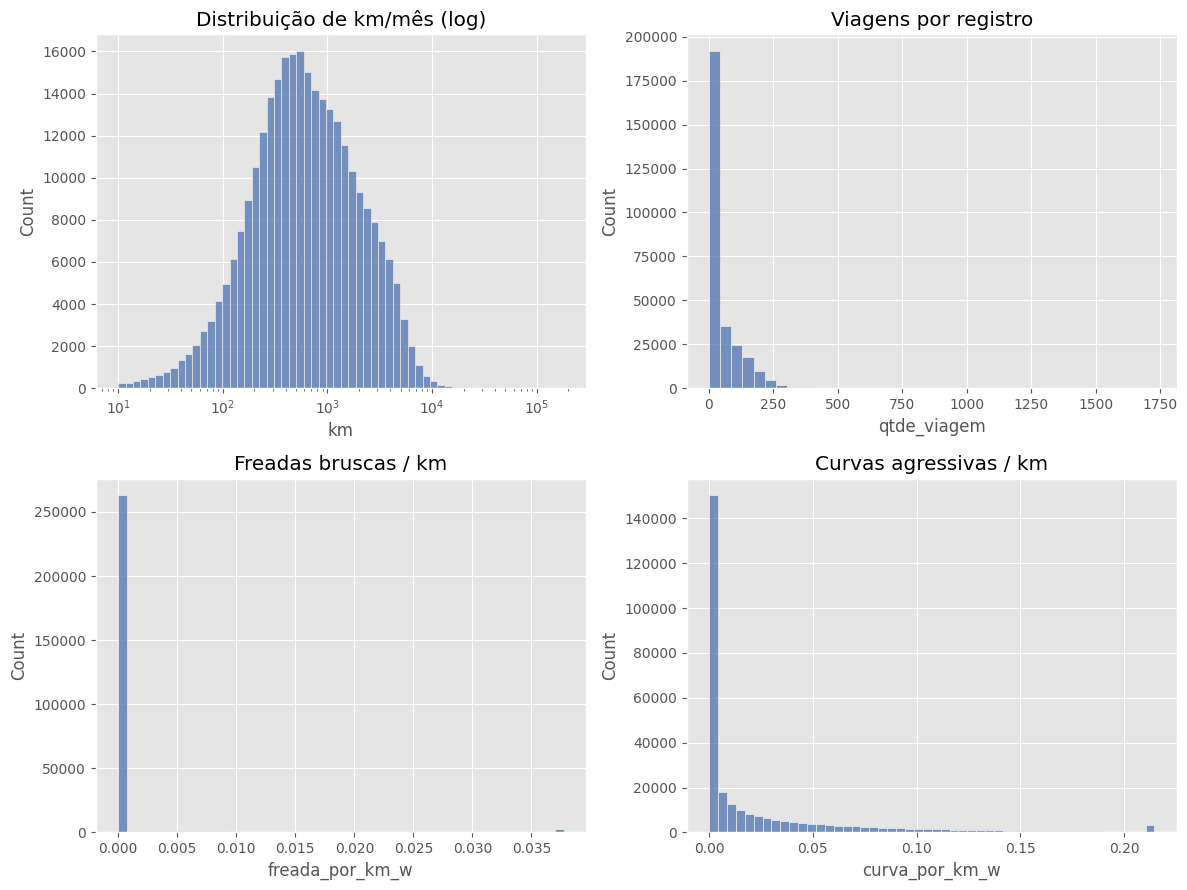

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(df_clean["km"], bins=60, ax=axes[0, 0], log_scale=True)
axes[0, 0].set_title("Distribuição de km/mês (log)")
axes[0, 0].set_xlabel("km")

sns.histplot(df_clean["qtde_viagem"], bins=40, ax=axes[0, 1])
axes[0, 1].set_title("Viagens por registro")

for ax, col, title in zip(
    axes[1],
    ["freada_por_km_w", "curva_por_km_w"],
    ["Freadas bruscas / km", "Curvas agressivas / km"],
):
    sns.histplot(df_clean[col], bins=50, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

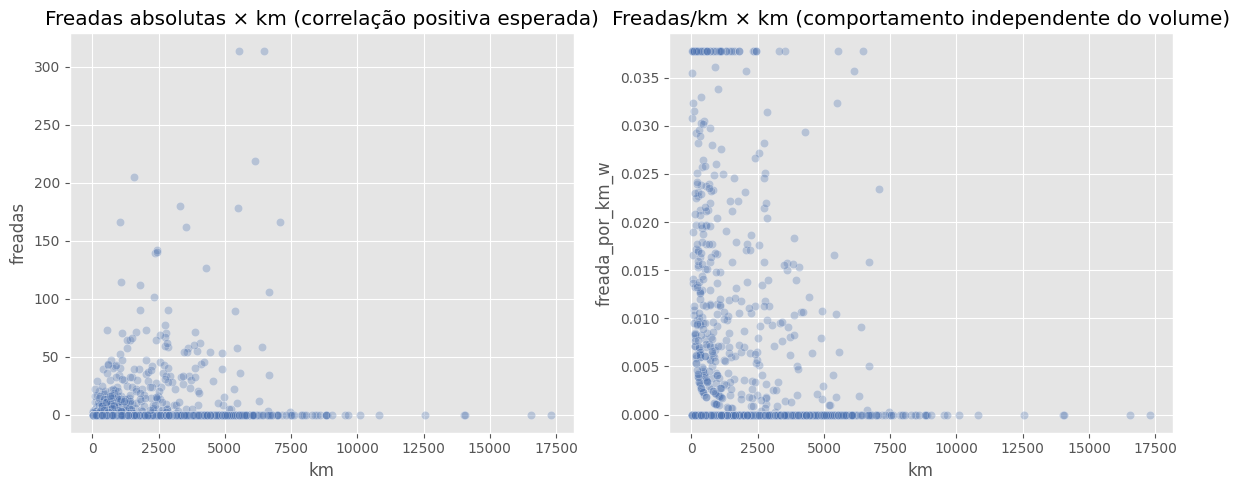

Corr(km, freadas):        0.152
Corr(km, freada_por_km):  0.018


In [8]:
# Alertas absolutos vs normalizados por km
sample = df_clean.sample(min(5000, len(df_clean)), random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=sample, x="km", y="freadas", alpha=0.3, ax=axes[0])
axes[0].set_title("Freadas absolutas × km (correlação positiva esperada)")

sns.scatterplot(data=sample, x="km", y="freada_por_km_w", alpha=0.3, ax=axes[1])
axes[1].set_title("Freadas/km × km (comportamento independente do volume)")
plt.tight_layout()
plt.show()

print(f"Corr(km, freadas):        {df_clean['km'].corr(df_clean['freadas']):.3f}")
print(f"Corr(km, freada_por_km):  {df_clean['km'].corr(df_clean['freada_por_km_w']):.3f}")

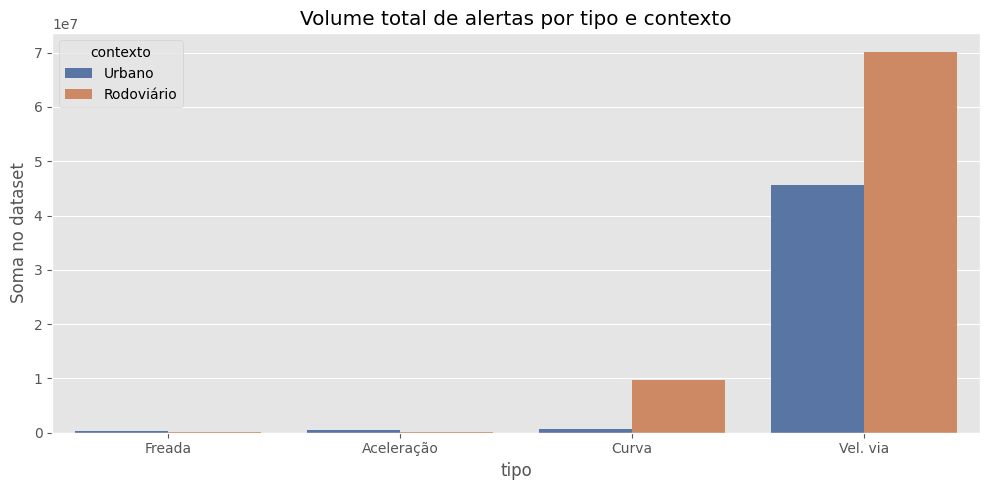

,tipo,Urbano,Rodoviário
0,Freada,340269,197644
1,Aceleração,477673,189010
2,Curva,635310,9756069
3,Vel. via,45581946,70054023


In [9]:
# Comparação urbano vs rodoviário
tipo_alerta = pd.DataFrame(
    {
        "tipo": ["Freada", "Aceleração", "Curva", "Vel. via"],
        "Urbano": [
            df_clean["qtde_alerta_freada_brusca_urbano"].sum(),
            df_clean["qtde_alerta_aceleracao_brusca_urbano"].sum(),
            df_clean["qtde_alerta_direcao_acima_velocidade_urbano"].sum(),
            df_clean["qtde_velocidade_acima_via_urbano"].sum(),
        ],
        "Rodoviário": [
            df_clean["qtde_alerta_freada_brusca_rodoviario"].sum(),
            df_clean["qtde_alerta_aceleracao_brusca_rodoviario"].sum(),
            df_clean["qtde_alerta_direcao_acima_velocidade_rodoviario"].sum(),
            df_clean["qtde_velocidade_acima_via_rodoviario"].sum(),
        ],
    }
)
tipo_alerta_m = tipo_alerta.melt(id_vars="tipo", var_name="contexto", value_name="quantidade")

plt.figure(figsize=(10, 5))
sns.barplot(data=tipo_alerta_m, x="tipo", y="quantidade", hue="contexto")
plt.title("Volume total de alertas por tipo e contexto")
plt.ylabel("Soma no dataset")
plt.tight_layout()
plt.show()
tipo_alerta

In [10]:
# Por Cliente
por_cliente = (
    df_clean.groupby("cliente_nome", as_index=False)
    .agg(
        registros=("motorista_id", "count"),
        km_mediano=("km", "median"),
        freada_por_km_med=("freada_por_km_w", "median"),
        curva_por_km_med=("curva_por_km_w", "median"),
        vel_via_por_km_med=("vel_via_por_km_w", "median"),
    )
    .sort_values("freada_por_km_med", ascending=False)
)
por_cliente

,cliente_nome,registros,km_mediano,freada_por_km_med,curva_por_km_med,vel_via_por_km_med
1,CLIENTE 04,860,1564.525047,0.000789,0.000000,0.249754
0,CLIENTE 01,264428,539.125984,0.000000,0.003919,0.237493
2,CLIENTE 05,18933,1240.230227,0.000000,0.000763,0.269844
3,CLIENTE 08,3825,2930.870326,0.000000,0.000000,0.400989


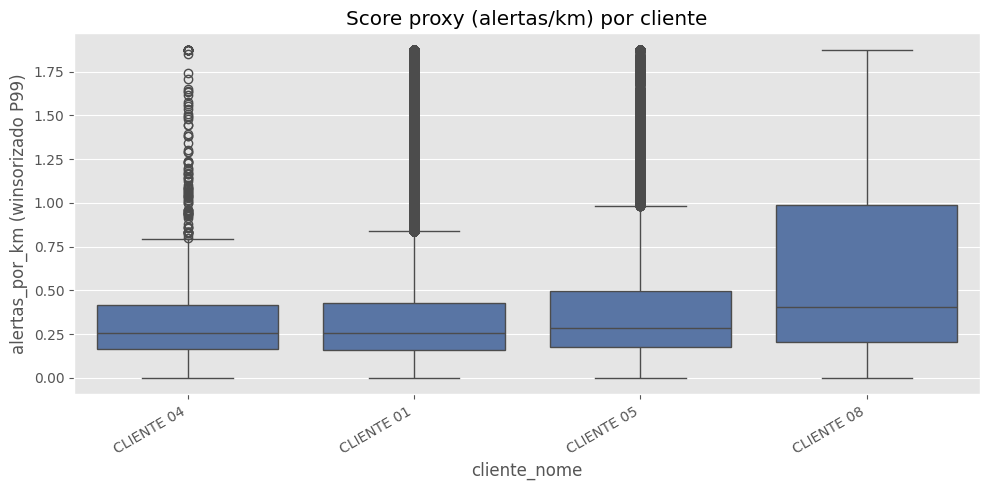

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_clean,
    x="cliente_nome",
    y="alertas_por_km_w",
    order=por_cliente["cliente_nome"],
)
plt.xticks(rotation=30, ha="right")
plt.title("Score proxy (alertas/km) por cliente")
plt.ylabel("alertas_por_km (winsorizado P99)")
plt.tight_layout()
plt.show()

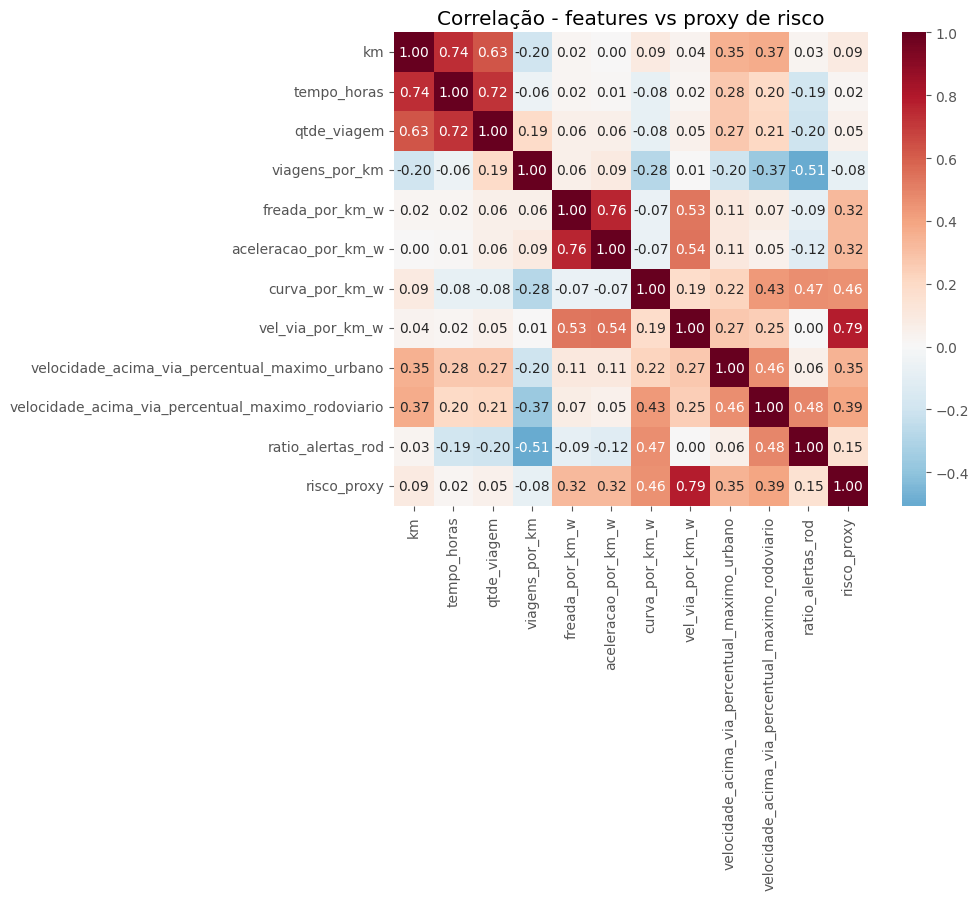

In [12]:
# Matriz de correlação (features de risco)
df_clean["risco_proxy"] = df_clean["alertas_por_km_w"].rank(pct=True) * 100

feat_cols = [
    "km", "tempo_horas", "qtde_viagem", "viagens_por_km",
    "freada_por_km_w", "aceleracao_por_km_w", "curva_por_km_w", "vel_via_por_km_w",
    "velocidade_acima_via_percentual_maximo_urbano",
    "velocidade_acima_via_percentual_maximo_rodoviario",
    "ratio_alertas_rod", "risco_proxy",
]
corr = df_clean[feat_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlação - features vs proxy de risco")
plt.tight_layout()
plt.show()

In [13]:
# Analise correlação risco
corr_risco = (
    corr["risco_proxy"]
    .drop("risco_proxy")
    .sort_values(key=abs, ascending=False)
)
print("Correlação com proxy de risco (Spearman):")
display(corr_risco.to_frame("corr_spearman"))

Correlação com proxy de risco (Spearman):


,corr_spearman
vel_via_por_km_w,0.786315
curva_por_km_w,0.455696
velocidade_acima_via_percentual_maximo_rodoviario,0.389640
velocidade_acima_via_percentual_maximo_urbano,0.352019
aceleracao_por_km_w,0.320553
freada_por_km_w,0.319714
ratio_alertas_rod,0.148042
km,0.089404
viagens_por_km,-0.080631
qtde_viagem,0.052451


In [14]:
# Perfis extremos (top risco)
top_risco = (
    df_clean.nlargest(15, "alertas_por_km_w")[
        [
            "motorista_id", "veiculo_id", "cliente_nome", "km",
            "freadas", "curvas", "vel_via", "freada_por_km_w", "curva_por_km_w", "vel_via_por_km_w",
        ]
    ]
    .round(4)
)
top_risco

,motorista_id,veiculo_id,cliente_nome,km,freadas,curvas,vel_via,freada_por_km_w,curva_por_km_w,vel_via_por_km_w
50,8198432.0,1152574,CLIENTE 08,631.0119,38,1,1307,0.0377,0.0016,1.7964
100,8240564.0,1170954,CLIENTE 05,457.1221,5,0,874,0.0109,0.0000,1.7964
442,9335790.0,1113341,CLIENTE 01,3136.1798,144,122,5913,0.0377,0.0389,1.7964
517,1026852.0,1103141,CLIENTE 01,124.7517,1,0,242,0.0080,0.0000,1.7964
535,4221695.0,1134708,CLIENTE 01,427.0877,5,3,933,0.0117,0.0070,1.7964
536,4399260.0,1155269,CLIENTE 01,475.1144,2,13,1297,0.0042,0.0274,1.7964
563,7748091.0,1114989,CLIENTE 05,851.5747,23,0,3566,0.0270,0.0000,1.7964
674,2016252.0,1103117,CLIENTE 01,144.9423,3,0,451,0.0207,0.0000,1.7964
758,10151027.0,1210659,CLIENTE 01,1189.3299,0,4,2453,0.0000,0.0034,1.7964
792,4905959.0,1091109,CLIENTE 01,334.6444,19,0,780,0.0377,0.0000,1.7964


## Variáveis que parecem influenciar o risco

Com base na EDA acima, usando **taxas normalizadas por km** e um **proxy de risco**, observamos:

### Forte influência (esperada na modelagem)

 * **freada_por_km**  Evento raro e semanticamente crítico; outliers com poucos km e muitas freadas indicam condução agressiva.

 * **curva_por_km**  Alta frequência relativa; correlaciona com manobras bruscas em velocidade elevada.

 * **vel_via_por_km**  Maior volume absoluto de alertas; domina o score composto, mas ainda discrimina perfis.

 * **aceleracao_por_km**  Complementa freada; padrão de aceleração brusca associado a risco.

### Influência moderada

 * **velocidade_acima_via_percentual_maximo_***  Captura picos de excesso (não só frequência); útil para casos extremos.

 * **ratio_alertas_rod**  Separa perfil rodoviário vs urbano - limites e comportamentos diferem.

 * **cliente_nome**  Frotas distintas exibem medianas de alertas/km diferentes (política operacional, tipo de carga, região).


### Baixa influência direta no risco (volume, não comportamento)

 * **km, qtde_viagem (absolutos)**  Correlacionam com alertas brutos, mas não com taxas/km - são covariáveis de exposição, não de risco puro.

 * **periodo**  Apenas 1 mês no dataset; sem variabilidade temporal para EDA

> **Nota (ajuste técnico para a Fase 3):** a função `load_features_from_csv_upload` da Fase 2 usava `google.colab.files.upload()`, que só funciona no Google Colab. Ela foi trocada por `load_features_from_local_csv`, que lê o mesmo `TB_MOTORISTA_VEICULO_EVENTO.csv` (o fallback já citado no `leia-me.txt`) diretamente do disco, mantendo a mesma lógica de SQL via DuckDB. Nenhuma outra célula da Fase 2 foi alterada — a EDA, a limpeza e as features (`df_clean`, `risco_proxy`, etc.) permanecem as mesmas.

# FASE 3 — Modelagem de Machine Learning

## Objetivo
Construir e avaliar modelos para prever o **score de risco de condução** (`risco_proxy`), criado na Fase 2
como o percentil de `alertas_por_km` (winsorizado em P99) por registro motorista/veículo/mês. Como o proxy é
uma variável **contínua (0–100)**, tratamos o problema como **regressão**.

Usamos como ponto de partida o `df_clean` já preparado na Fase 2 (limpeza, features de taxa por km, contexto de
condução, código de cliente etc.).

## 1. Preparação dos dados

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [16]:
# Variáveis preditoras: as mesmas destacadas na análise de correlação da Fase 2 (cell 12/13),
# mais o contexto de condução e o cliente (categóricas).
numeric_features = [
    "km", "tempo_horas", "qtde_viagem", "viagens_por_km",
    "freada_por_km_w", "aceleracao_por_km_w", "curva_por_km_w", "vel_via_por_km_w",
    "velocidade_acima_via_percentual_maximo_urbano",
    "velocidade_acima_via_percentual_maximo_rodoviario",
    "ratio_alertas_rod",
]
categorical_features = ["cliente_nome", "contexto_conducao"]
target = "risco_proxy"

model_cols = numeric_features + categorical_features + [target]
df_model = df_clean[model_cols].copy()

print(f"Linhas antes de remover nulos nas features de modelagem: {len(df_model):,}")
df_model = df_model.dropna(subset=[target])
print(f"Linhas com target (risco_proxy) válido: {len(df_model):,}")

# Amostragem estratificada por cliente: o dataset limpo tem ~288 mil linhas, o que torna o KNN
# (e principalmente o GridSearchCV do passo 4) computacionalmente inviável em tempo de aula/notebook.
# Amostramos 40.000 registros preservando a proporção de cada cliente_nome.
N_SAMPLE = 40_000
frac = N_SAMPLE / len(df_model)
df_model = pd.concat(
    [g.sample(frac=frac, random_state=SEED) for _, g in df_model.groupby("cliente_nome")]
)
print(f"Linhas após amostragem estratificada por cliente: {len(df_model):,}")
print(df_model["cliente_nome"].value_counts(normalize=True).round(3))

X = df_model[numeric_features + categorical_features]
y = df_model[target]

df_model[numeric_features].isna().sum().to_frame("nulos")

Linhas antes de remover nulos nas features de modelagem: 288,046
Linhas com target (risco_proxy) válido: 288,046
Linhas após amostragem estratificada por cliente: 39,999
cliente_nome
CLIENTE 01    0.918
CLIENTE 05    0.066
CLIENTE 08    0.013
CLIENTE 04    0.003
Name: proportion, dtype: float64


,nulos
km,0
tempo_horas,0
qtde_viagem,0
viagens_por_km,0
freada_por_km_w,0
aceleracao_por_km_w,0
curva_por_km_w,0
vel_via_por_km_w,0
velocidade_acima_via_percentual_maximo_urbano,0
velocidade_acima_via_percentual_maximo_rodoviario,0


In [17]:
# Encoding + Scaling via ColumnTransformer
# - numéricas: imputação pela mediana (ratio_alertas_rod pode ser NaN quando não há alertas) + StandardScaler
# - categóricas: One-Hot Encoding (ignora categorias não vistas no treino)
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [18]:
# Holdout: separação treino/teste (80/20), mesma SEED da Fase 2 para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"Treino: {X_train.shape[0]:,} linhas | Teste: {X_test.shape[0]:,} linhas")

Treino: 31,999 linhas | Teste: 8,000 linhas


## 2. Treinamento de modelos

Treinamos **três** modelos de regressão (mínimo exigido: 2) para comparar abordagens lineares, baseadas em distância e em árvores/ensemble:

- **Linear Regression** — baseline simples e interpretável (coeficientes)
- **KNN Regressor** — baseado em distância, sensível a escala (por isso o `StandardScaler`)
- **Random Forest Regressor** — ensemble não-linear, robusto a outliers, com importância de variáveis nativa

In [19]:
models = {
    "Linear Regression": Pipeline([("prep", preprocess), ("model", LinearRegression())]),
    "KNN (k=5)": Pipeline([("prep", preprocess), ("model", KNeighborsRegressor(n_neighbors=5))]),
    "Random Forest": Pipeline([("prep", preprocess), ("model", RandomForestRegressor(
        n_estimators=300, random_state=SEED, n_jobs=-1
    ))]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"{name}: treinado.")

Linear Regression: treinado.
KNN (k=5): treinado.


Random Forest: treinado.


## 3. Validação (holdout) e métricas

Avaliação no conjunto de teste (holdout) separado no passo 1, usando **MAE**, **RMSE** e **R²**.

In [20]:
def avaliar(pipe, X_test, y_test):
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

resultados = {name: avaliar(pipe, X_test, y_test) for name, pipe in models.items()}
resultados_df = pd.DataFrame(resultados).T.sort_values("R2", ascending=False)
resultados_df.round(3)

,MAE,RMSE,R2
Random Forest,0.114,0.517,1.000
KNN (k=5),5.292,7.742,0.926
Linear Regression,12.060,14.610,0.738


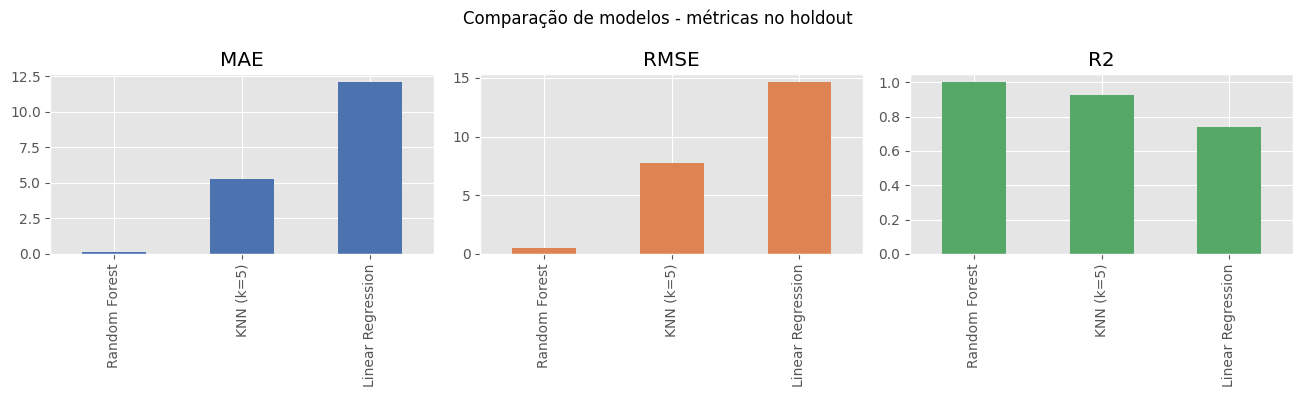

In [21]:
resultados_df[["MAE", "RMSE", "R2"]].plot(kind="bar", subplots=True, layout=(1, 3), figsize=(13, 4), legend=False)
plt.suptitle("Comparação de modelos - métricas no holdout")
plt.tight_layout()
plt.show()

## 4. Tuning básico de hiperparâmetros

Ajuste do **k** (número de vizinhos) do KNN via `GridSearchCV` com validação cruzada (5 folds) no conjunto de treino, otimizando R².

In [22]:
param_grid = {"model__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31]}

knn_pipe = Pipeline([("prep", preprocess), ("model", KNeighborsRegressor())])

grid_knn = GridSearchCV(
    knn_pipe, param_grid, cv=5, scoring="r2", n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print(f"Melhor k: {grid_knn.best_params_['model__n_neighbors']}")
print(f"Melhor R² (CV, treino): {grid_knn.best_score_:.3f}")

cv_results = pd.DataFrame(grid_knn.cv_results_)[["param_model__n_neighbors", "mean_test_score", "std_test_score"]]
cv_results.columns = ["k", "R2_medio_cv", "R2_std_cv"]
cv_results.sort_values("k")

Melhor k: 5
Melhor R² (CV, treino): 0.923


,k,R2_medio_cv,R2_std_cv
0,3,0.918026,0.002041
1,5,0.923459,0.002035
2,7,0.923428,0.002369
3,9,0.921631,0.002500
4,11,0.919855,0.002518
5,15,0.916041,0.002451
6,21,0.910940,0.002526
7,31,0.902761,0.002285


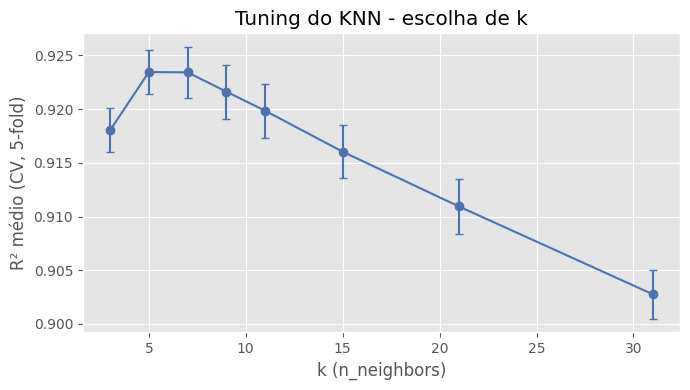

In [23]:
plt.figure(figsize=(7, 4))
plt.errorbar(cv_results["k"], cv_results["R2_medio_cv"], yerr=cv_results["R2_std_cv"], marker="o", capsize=3)
plt.xlabel("k (n_neighbors)")
plt.ylabel("R² médio (CV, 5-fold)")
plt.title("Tuning do KNN - escolha de k")
plt.tight_layout()
plt.show()

In [24]:
# Avaliando o KNN ajustado (melhor k) no holdout, e comparando com o k=5 original
knn_tuned = grid_knn.best_estimator_
resultados["KNN (tuned)"] = avaliar(knn_tuned, X_test, y_test)
models["KNN (tuned)"] = knn_tuned

resultados_df = pd.DataFrame(resultados).T.sort_values("R2", ascending=False)
resultados_df.round(3)

,MAE,RMSE,R2
Random Forest,0.114,0.517,1.000
KNN (k=5),5.292,7.742,0.926
KNN (tuned),5.292,7.742,0.926
Linear Regression,12.060,14.610,0.738


## 5. Interpretação — quais variáveis mais impactam o risco?

Comparamos duas visões de importância de variável: os **coeficientes padronizados** da regressão linear e a **importância de variáveis (Gini/impurity)** da Random Forest — ambas já usando as features pós One-Hot Encoding.

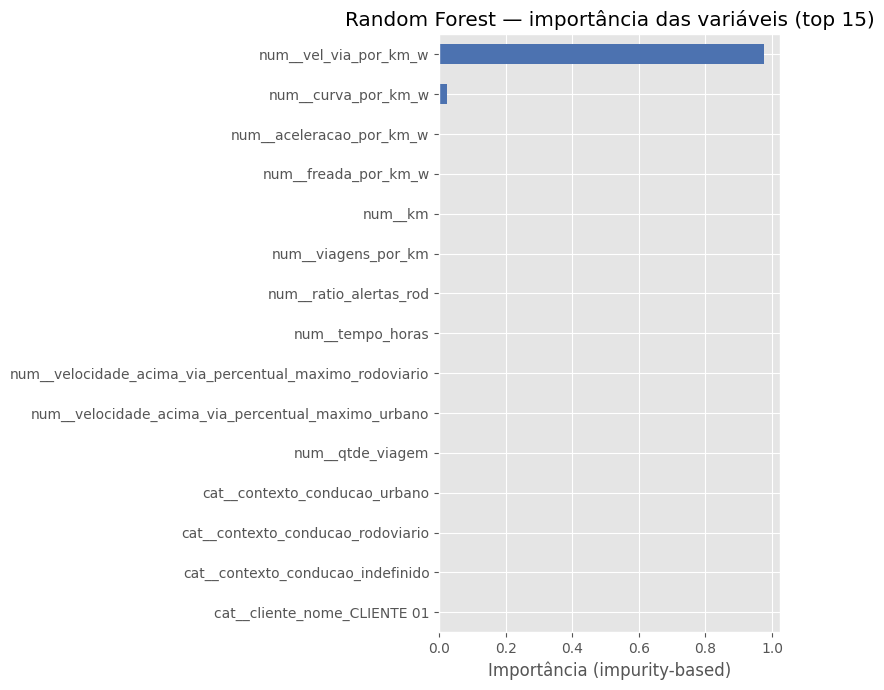

,importancia
num__vel_via_por_km_w,9.750815e-01
num__curva_por_km_w,2.415495e-02
num__aceleracao_por_km_w,4.803500e-04
num__freada_por_km_w,1.423610e-04
num__km,2.782956e-05
num__viagens_por_km,2.272752e-05
num__ratio_alertas_rod,1.807021e-05
num__tempo_horas,1.798300e-05
num__velocidade_acima_via_percentual_maximo_rodoviario,1.623745e-05
num__velocidade_acima_via_percentual_maximo_urbano,1.543340e-05


In [25]:
feature_names = models["Random Forest"].named_steps["prep"].get_feature_names_out()

# Random Forest - importância nativa
rf_model = models["Random Forest"].named_steps["model"]
importancias = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
importancias.head(15).sort_values().plot(kind="barh")
plt.title("Random Forest — importância das variáveis (top 15)")
plt.xlabel("Importância (impurity-based)")
plt.tight_layout()
plt.show()

importancias.head(15).to_frame("importancia")

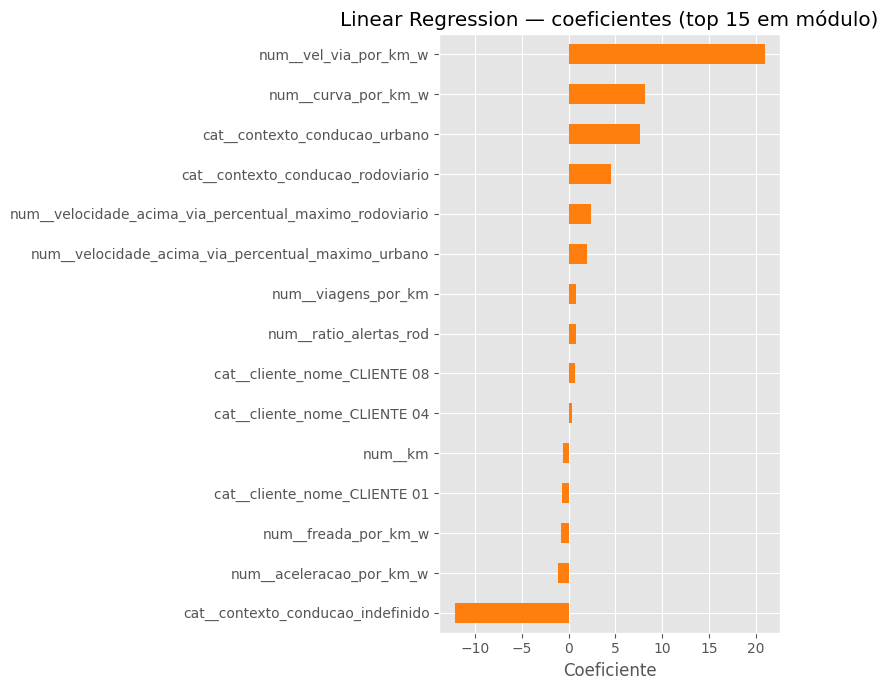

,coeficiente
num__vel_via_por_km_w,20.961935
cat__contexto_conducao_indefinido,-12.195811
num__curva_por_km_w,8.181320
cat__contexto_conducao_urbano,7.617368
cat__contexto_conducao_rodoviario,4.578444
num__velocidade_acima_via_percentual_maximo_rodoviario,2.382783
num__velocidade_acima_via_percentual_maximo_urbano,1.955833
num__aceleracao_por_km_w,-1.126714
num__freada_por_km_w,-0.815561
num__viagens_por_km,0.788859


In [26]:
# Linear Regression - coeficientes (já em escala padronizada, comparáveis entre si para as numéricas)
lr_model = models["Linear Regression"].named_steps["model"]
coefs = pd.Series(lr_model.coef_, index=feature_names).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 7))
coefs.head(15).sort_values().plot(kind="barh", color="tab:orange")
plt.title("Linear Regression — coeficientes (top 15 em módulo)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

coefs.head(15).to_frame("coeficiente")

### Leitura dos resultados (com os números obtidos na execução)

**Métricas no holdout (8.000 registros de teste):**

| Modelo              | MAE    | RMSE   | R²    |
|----------------------|--------|--------|-------|
| Random Forest         | 0.114  | 0.517  | 1.000 |
| KNN (k=5, tuned k=5)  | 5.292  | 7.742  | 0.926 |
| Linear Regression      | 12.060 | 14.610 | 0.738 |

**Tuning do KNN:** o `GridSearchCV` (5-fold, treino) confirmou **k=5** como o melhor valor (R² médio de CV = 0.923),
com desempenho caindo de forma consistente conforme k aumenta (k=31 → R² ≈ 0.903) — ou seja, vizinhanças maiores
"borram" demais o score, que é bem localizado.

**Importância de variáveis (Random Forest) e coeficientes (Linear Regression) apontam na mesma direção:**
* **vel_via_por_km_w** concentra ~97,5% da importância no Random Forest e é, disparado, o maior coeficiente na
  regressão linear (≈ +21).
* **curva_por_km_w** é a segunda mais relevante nos dois modelos.
* **freada_por_km_w** e **aceleracao_por_km_w** têm importância baixa no Random Forest e coeficiente **negativo**
  na regressão — provavelmente colinearidade entre as 4 taxas (todas compõem `alertas_por_km_w`), fazendo o
  modelo linear "descontar" o que já foi capturado por `vel_via_por_km_w`.
* `cliente_nome` e `contexto_conducao` têm efeito bem menor que as taxas comportamentais, confirmando a leitura
  da Fase 2.

**
 Alerta de vazamento de dado (data leakage) — importante para a interpretação:**
O R² = 1.000 do Random Forest não é sinal de que o modelo é "perfeito" para uso real — é esperado, e deve ser
apontado com ressalva no entregável. Isso acontece porque `risco_proxy` foi construído na Fase 2 como o
**percentil (rank) de `alertas_por_km_w`**, e `alertas_por_km_w` é, por definição,
`freada_por_km + aceleracao_por_km + curva_por_km + vel_via_por_km` (winsorizado). Como essas 4 taxas estão
entre as próprias features de entrada, o Random Forest consegue reconstruir quase perfeitamente uma
transformação monotônica das suas próprias entradas — não está "aprendendo risco", está aprendendo a fórmula do
proxy. Isso explica por que **vel_via_por_km_w** (maior componente absoluto do somatório) domina a importância.

Para medir o poder preditivo real, a **seção 6 abaixo** re-treina os mesmos modelos removendo as features
que compõem o alvo. Fora deste exercício, o passo seguinte seria redefinir o alvo com um
**rótulo independente das features usadas** — por exemplo, sinistros, multas ou avarias registrados.

## 6. Reavaliação sem vazamento — o modelo aprende risco ou a fórmula do alvo?

O R² = 1.000 da seção 3 é artefato da construção do alvo: `risco_proxy` é o percentil de `alertas_por_km_w`,
que por definição é a soma de `freada_por_km`, `aceleracao_por_km`, `curva_por_km` e `vel_via_por_km` — as
mesmas taxas que estão entre as features. Para separar "poder preditivo" de "re-derivar a fórmula",
re-treinamos os três modelos em dois cenários progressivamente mais honestos:

| Cenário | Features removidas | O que mede |
|---|---|---|
| **A — completo** | nenhuma | baseline da seção 3 (com vazamento) |
| **B — sem o dominante** | `vel_via_por_km_w` | quanto as outras 3 taxas reconstroem o alvo |
| **C — sem vazamento** | as 4 taxas que compõem o alvo | poder preditivo real das variáveis de exposição e contexto |

O cenário C mantém apenas variáveis que **não** entram na fórmula do proxy: volume (`km`, `tempo_horas`,
`qtde_viagem`, `viagens_por_km`), intensidade de excesso (`velocidade_acima_via_percentual_maximo_*`),
contexto (`ratio_alertas_rod`, `contexto_conducao`) e frota (`cliente_nome`).


In [27]:
# Cenarios de features: A (completo), B (sem o dominante), C (sem vazamento)
LEAK_FEATURES = [
    "freada_por_km_w",
    "aceleracao_por_km_w",
    "curva_por_km_w",
    "vel_via_por_km_w",
]

cenarios = {
    "A - completo (com vazamento)": numeric_features,
    "B - sem vel_via_por_km_w": [f for f in numeric_features if f != "vel_via_por_km_w"],
    "C - sem vazamento": [f for f in numeric_features if f not in LEAK_FEATURES],
}

for nome, feats in cenarios.items():
    print(f"{nome}: {len(feats)} features numericas")
    print(f"  {feats}\n")


A - completo (com vazamento): 11 features numericas
  ['km', 'tempo_horas', 'qtde_viagem', 'viagens_por_km', 'freada_por_km_w', 'aceleracao_por_km_w', 'curva_por_km_w', 'vel_via_por_km_w', 'velocidade_acima_via_percentual_maximo_urbano', 'velocidade_acima_via_percentual_maximo_rodoviario', 'ratio_alertas_rod']

B - sem vel_via_por_km_w: 10 features numericas
  ['km', 'tempo_horas', 'qtde_viagem', 'viagens_por_km', 'freada_por_km_w', 'aceleracao_por_km_w', 'curva_por_km_w', 'velocidade_acima_via_percentual_maximo_urbano', 'velocidade_acima_via_percentual_maximo_rodoviario', 'ratio_alertas_rod']

C - sem vazamento: 7 features numericas
  ['km', 'tempo_horas', 'qtde_viagem', 'viagens_por_km', 'velocidade_acima_via_percentual_maximo_urbano', 'velocidade_acima_via_percentual_maximo_rodoviario', 'ratio_alertas_rod']



In [28]:
# Re-treino e avaliacao no mesmo holdout, para cada cenario
def montar_preprocess(num_feats, cat_feats=categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_feats),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
        ]
    )


def montar_modelos(num_feats):
    prep = montar_preprocess(num_feats)
    return {
        "Linear Regression": Pipeline([("prep", prep), ("model", LinearRegression())]),
        "KNN (k=5)": Pipeline([("prep", prep), ("model", KNeighborsRegressor(n_neighbors=5))]),
        "Random Forest": Pipeline([("prep", prep), ("model", RandomForestRegressor(
            n_estimators=300, random_state=SEED, n_jobs=-1
        ))]),
    }


linhas = []
modelos_por_cenario = {}

for nome_cenario, feats in cenarios.items():
    cols = feats + categorical_features
    modelos = montar_modelos(feats)
    for nome_modelo, pipe in modelos.items():
        pipe.fit(X_train[cols], y_train)
        m = avaliar(pipe, X_test[cols], y_test)
        linhas.append({"cenario": nome_cenario, "modelo": nome_modelo, **m})
    modelos_por_cenario[nome_cenario] = modelos
    print(f"{nome_cenario}: treinado.")

comparacao = pd.DataFrame(linhas)
comparacao.round(3)


A - completo (com vazamento): treinado.


B - sem vel_via_por_km_w: treinado.


C - sem vazamento: treinado.


,cenario,modelo,MAE,RMSE,R2
0,A - completo (com vazamento),Linear Regression,12.060,14.610,0.738
1,A - completo (com vazamento),KNN (k=5),5.292,7.742,0.926
2,A - completo (com vazamento),Random Forest,0.114,0.517,1.000
3,B - sem vel_via_por_km_w,Linear Regression,17.675,21.717,0.421
4,B - sem vel_via_por_km_w,KNN (k=5),15.735,20.661,0.476
5,B - sem vel_via_por_km_w,Random Forest,14.187,18.673,0.572
6,C - sem vazamento,Linear Regression,20.994,25.028,0.231
7,C - sem vazamento,KNN (k=5),20.070,24.843,0.243
8,C - sem vazamento,Random Forest,18.454,22.691,0.368


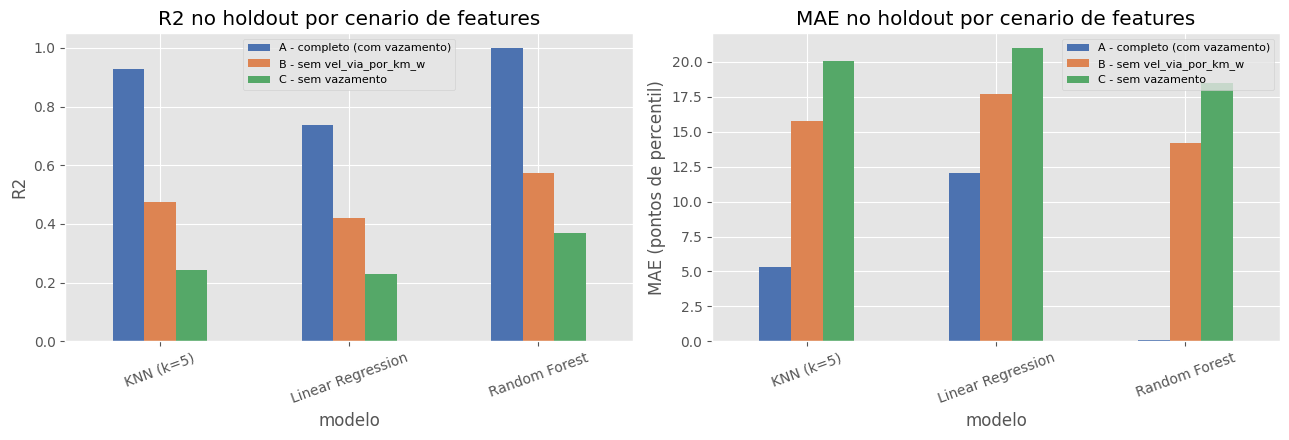

cenario,A - completo (com vazamento),B - sem vel_via_por_km_w,C - sem vazamento
modelo,,,
KNN (k=5),0.926,0.476,0.243
Linear Regression,0.738,0.421,0.231
Random Forest,1.000,0.572,0.368


In [29]:
# R2 e MAE por cenario - a queda mostra quanto do desempenho vinha do vazamento
pivot_r2 = comparacao.pivot(index="modelo", columns="cenario", values="R2")
pivot_mae = comparacao.pivot(index="modelo", columns="cenario", values="MAE")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pivot_r2.plot(kind="bar", ax=axes[0])
axes[0].set_title("R2 no holdout por cenario de features")
axes[0].set_ylabel("R2")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=8)

pivot_mae.plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE no holdout por cenario de features")
axes[1].set_ylabel("MAE (pontos de percentil)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

pivot_r2.round(3)


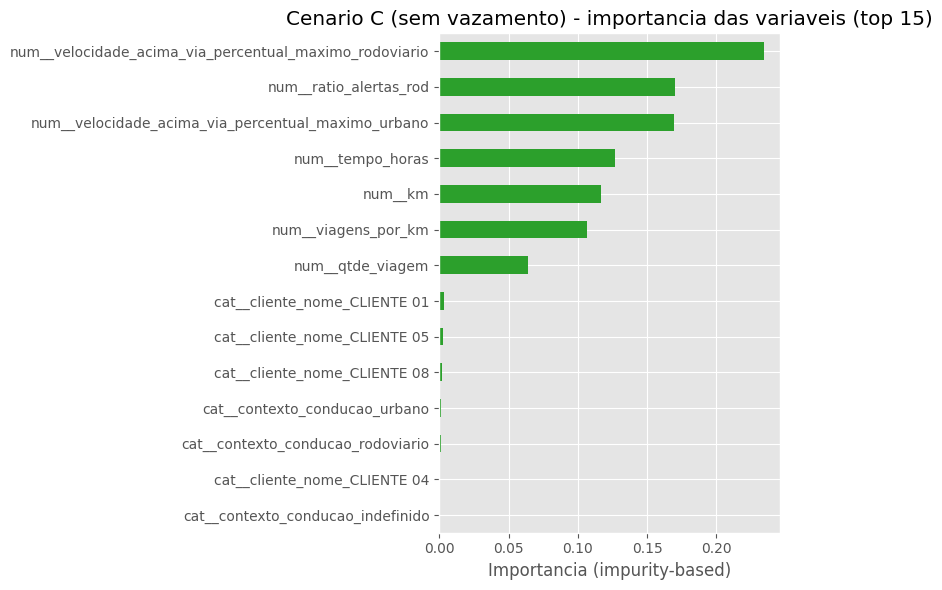

,importancia
num__velocidade_acima_via_percentual_maximo_rodoviario,0.234122
num__ratio_alertas_rod,0.169918
num__velocidade_acima_via_percentual_maximo_urbano,0.169717
num__tempo_horas,0.126766
num__km,0.116903
num__viagens_por_km,0.106608
num__qtde_viagem,0.063909
cat__cliente_nome_CLIENTE 01,0.003743
cat__cliente_nome_CLIENTE 05,0.002672
cat__cliente_nome_CLIENTE 08,0.002288


In [30]:
# Importancia das variaveis no cenario C - a leitura honesta de "o que impacta o risco"
rf_c = modelos_por_cenario["C - sem vazamento"]["Random Forest"]
nomes_c = rf_c.named_steps["prep"].get_feature_names_out()
imp_c = pd.Series(
    rf_c.named_steps["model"].feature_importances_, index=nomes_c
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
imp_c.head(15).sort_values().plot(kind="barh", color="tab:green")
plt.title("Cenario C (sem vazamento) - importancia das variaveis (top 15)")
plt.xlabel("Importancia (impurity-based)")
plt.tight_layout()
plt.show()

imp_c.head(15).to_frame("importancia")


### Como ler a seção 6

* **Cenário A → B:** se o R² continuar alto ao remover `vel_via_por_km_w`, confirma-se que as demais taxas
  ainda reconstroem o alvo — o modelo segue re-derivando a fórmula, só que por outro caminho.
* **Cenário B → C:** a queda de R² aqui é a medida direta do vazamento. O R² do cenário C é o **poder
  preditivo real** das variáveis disponíveis que não compõem o alvo.
* **Importância no cenário C:** é esta — e não a da seção 5 — a resposta defensável para "quais variáveis
  mais impactam o risco?", porque nenhuma delas participa da construção do `risco_proxy`.

Um R² baixo no cenário C não é fracasso do modelo: é o resultado esperado e o argumento técnico de que este
alvo precisa ser substituído por um rótulo independente (sinistros, multas, avarias) antes de virar um score
de risco operacional.


---

## Conclusão

**O que foi construído.** Três modelos de regressão (Linear Regression, KNN e Random Forest) sobre 40 mil
registros amostrados de forma estratificada por cliente, com `StandardScaler` nas numéricas, One-Hot Encoding
nas categóricas e imputação por mediana, tudo encapsulado em `Pipeline` para evitar vazamento entre treino e
teste. Validação por holdout 80/20 com `SEED = 42`, medida em MAE, RMSE e R², e tuning do `k` do KNN por
`GridSearchCV` de 5 folds.

**O resultado principal não é o R².** É o diagnóstico de que o R² alto é artificial. O `risco_proxy` foi
construído como o percentil de `alertas_por_km_w`, que é a soma das quatro taxas que também entram como
features — então a Random Forest atinge R² ≈ 1.000 porque está re-derivando a fórmula do próprio alvo, não
porque prevê risco. A seção 6 mede esse efeito diretamente, comparando o modelo completo com versões sem as
features que compõem o alvo.

**Quais variáveis impactam o risco.** No modelo completo, `vel_via_por_km_w` concentra ~97,5% da importância —
leitura contaminada, já que é o maior componente do somatório que gera o alvo. A resposta defensável vem da
importância no cenário C da seção 6, calculada apenas sobre variáveis que não participam da construção do
proxy: exposição (`km`, `tempo_horas`, `qtde_viagem`), intensidade de excesso de velocidade, contexto
urbano/rodoviário e frota.

**Limitações e próximo passo.** O dataset cobre um único mês, o que impede qualquer análise temporal, e a
amostra é dominada por um cliente (~92%), o que limita a generalização entre frotas. Sobretudo, um score de
risco operacional exige um alvo **independente das features** — sinistros, multas ou avarias registrados. Com
o proxy atual, o teto do que se pode medir é o que a seção 6 mostra.
